# 05 — Sensitivity to kNN parameter k

**Purpose:** Test sensitivity to k (number of neighbors in the kNN graph). Vary k ∈ {10, 20, 30, 50}, compute spatial metrics, plot stabilization curves.

## Imports and path setup

In [ ]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

from thesis_layout import RAW_RESULTS, thesis_figure_dir

import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from scipy.sparse.csgraph import connected_components as sparse_connected_components

warnings.filterwarnings("ignore", message=".*not fully connected.*", category=UserWarning)

from analysis.experiment_runner import _get_run_dirs
from analysis.preprocessing import get_transformed_test_features
from analysis.run_analysis import load_meta, run_multiplicity, run_spatial

RESULTS_DIR = RAW_RESULTS
FIG_DIR = thesis_figure_dir("nb05")
FORCE_RECOMPUTE = False
CACHE_VERSION = "v1"
CACHE_DIR = ROOT / "thesis_outputs" / "cache" / "notebooks"
CACHE_DIR.mkdir(parents=True, exist_ok=True)

from analysis.cache import load_or_compute_df


## Loop over k and store results

In [2]:
K = 25
K_NN_LIST = [10, 20, 30, 50, 60, 70, 80, 90, 100]

SUPPORTED_DATASETS = ("compas", "german", "adult")
dataset_dirs = [p for p in RESULTS_DIR.iterdir() if p.is_dir() and p.name in SUPPORTED_DATASETS and _get_run_dirs(p)]


def compute_knn_sensitivity():
    def run_one_knn(run_dir, X_test, k_nn):
        n_cand = len(load_meta(run_dir))
        K_actual = min(K, n_cand)
        mult = run_multiplicity(run_dir, K=K_actual)
        spatial = run_spatial(run_dir, X_test, K=K_actual, k=k_nn)

        W = spatial["W"]
        W_sparse = W.to_sparse() if hasattr(W, "to_sparse") else W.sparse
        W_sym = W_sparse + W_sparse.T
        W_sym = (W_sym > 0).astype(int)
        n_comp, comp_labels = sparse_connected_components(W_sym, directed=False)
        comp_sizes = np.bincount(comp_labels)
        largest_frac = int(comp_sizes.max()) / W_sym.shape[0]

        return {
            "mean_variance": mult["mean_variance"],
            "mean_conflict": mult["mean_conflict"],
            "moran_i": spatial["moran_i"],
            "n_hh": int(np.sum(spatial["HH_mask"])),
            "conflict_moran_i": spatial.get("conflict_moran_i", np.nan),
            "conflict_n_hh": spatial.get("conflict_n_hh", 0),
            "n_components": n_comp,
            "largest_component_frac": largest_frac,
        }

    results_knn = []
    for dataset_dir in dataset_dirs:
        dataset_name = dataset_dir.name
        run_dirs = _get_run_dirs(dataset_dir)
        for k_nn_val in K_NN_LIST:
            for run_dir in run_dirs:
                X_test = get_transformed_test_features(run_dir, dataset_name)
                res = run_one_knn(run_dir, X_test, k_nn_val)
                results_knn.append({
                    "dataset": dataset_name,
                    "seed": run_dir.name,
                    "k_nn": k_nn_val,
                    **res,
                })
    return pd.DataFrame(results_knn)


def compute_knn_hh_overlay():
    """HH masks for PCA overlay plots (one row per test point)."""
    def run_one_knn_masks(run_dir, X_test, k_nn):
        n_cand = len(load_meta(run_dir))
        K_actual = min(K, n_cand)
        spatial = run_spatial(run_dir, X_test, K=K_actual, k=k_nn)
        hh_mask = np.asarray(spatial["HH_mask"], dtype=bool)
        return hh_mask

    rows = []
    for dataset_dir in dataset_dirs:
        dataset_name = dataset_dir.name
        for k_nn_val in K_NN_LIST:
            for run_dir in _get_run_dirs(dataset_dir):
                X_test = get_transformed_test_features(run_dir, dataset_name)
                hh_mask = run_one_knn_masks(run_dir, X_test, k_nn_val)
                for point_idx, is_hh in enumerate(hh_mask):
                    rows.append({
                        "dataset": dataset_name,
                        "seed": run_dir.name,
                        "k_nn": k_nn_val,
                        "point_idx": int(point_idx),
                        "is_hh": bool(is_hh),
                    })
    return pd.DataFrame(rows)


df_knn = load_or_compute_df(
    CACHE_DIR / f"nb05_knn_sensitivity_{CACHE_VERSION}.parquet",
    compute_knn_sensitivity,
    force=FORCE_RECOMPUTE,
)
df_hh_overlay = load_or_compute_df(
    CACHE_DIR / f"nb05_knn_hh_overlay_{CACHE_VERSION}.parquet",
    compute_knn_hh_overlay,
    force=FORCE_RECOMPUTE,
)
print(df_knn.groupby(["dataset", "k_nn"]).agg({
    "mean_variance": ["mean", "std"], "mean_conflict": ["mean", "std"],
    "moran_i": ["mean", "std"], "n_hh": "mean",
    "conflict_moran_i": ["mean", "std"], "conflict_n_hh": "mean",
    "n_components": ["mean", "min", "max"], "largest_component_frac": ["mean", "min"],
}).round(4))


             mean_variance         mean_conflict         moran_i          \
                      mean     std          mean     std    mean     std   
dataset k_nn                                                               
adult   10          0.0014  0.0001        0.0172  0.0011  0.1075  0.0277   
        20          0.0014  0.0001        0.0172  0.0011  0.0949  0.0249   
        30          0.0014  0.0001        0.0172  0.0011  0.0871  0.0241   
        50          0.0014  0.0001        0.0172  0.0011  0.0782  0.0227   
        60          0.0014  0.0001        0.0172  0.0011  0.0749  0.0219   
        70          0.0014  0.0001        0.0172  0.0011  0.0726  0.0212   
        80          0.0014  0.0001        0.0172  0.0011  0.0701  0.0207   
        90          0.0014  0.0001        0.0172  0.0011  0.0686  0.0205   
        100         0.0014  0.0001        0.0172  0.0011  0.0672  0.0202   
compas  10          0.0013  0.0003        0.0354  0.0070  0.3117  0.1075   
        20  

## Stabilization curves

Mean ± std bands over seeds for variance-based and conflict-based metrics, plus mean_variance to confirm it is constant w.r.t. k.

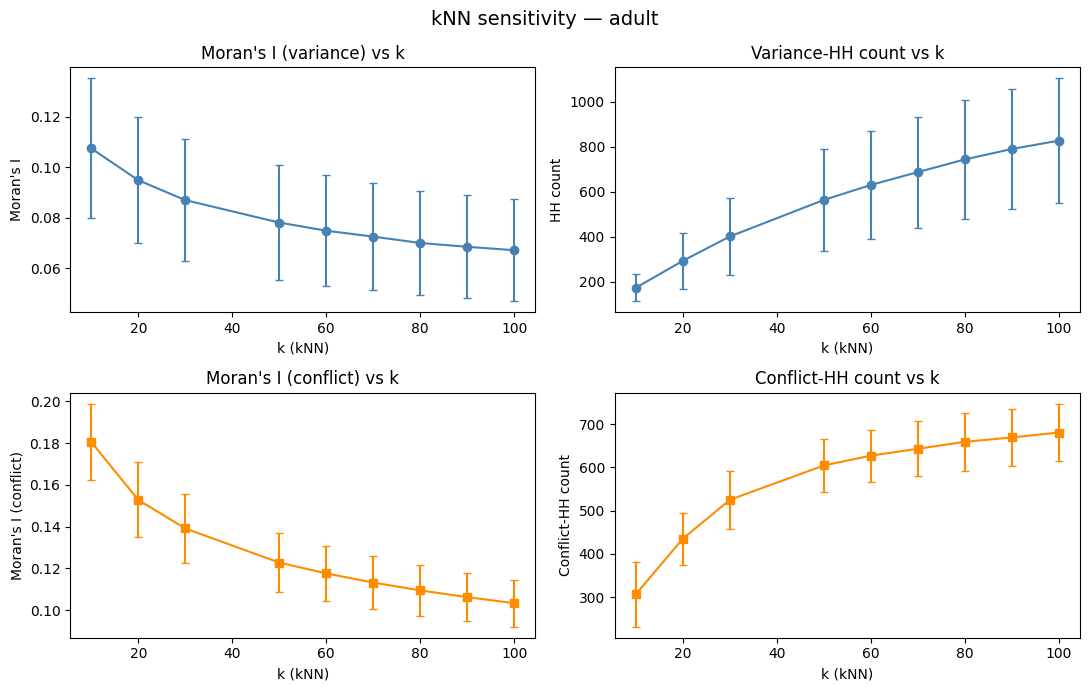

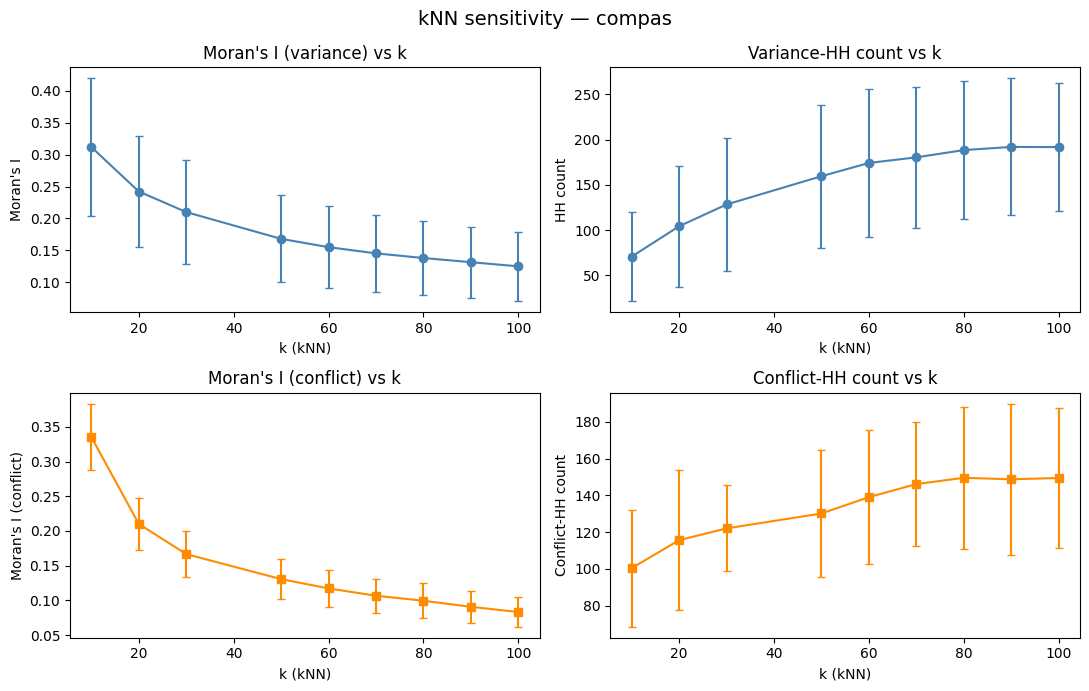

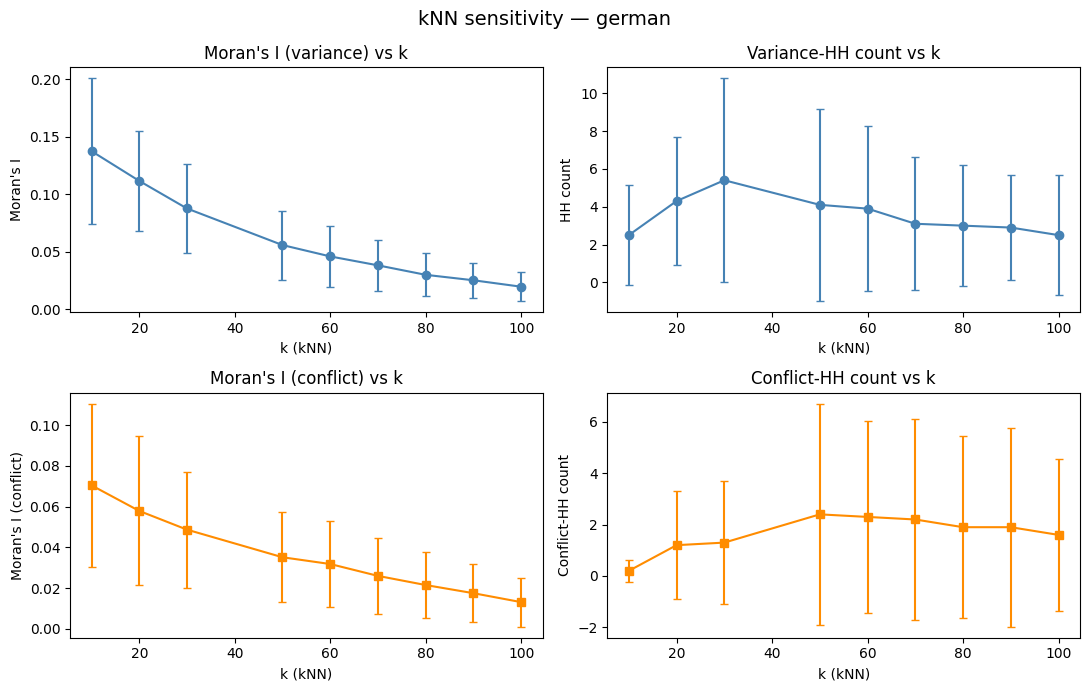

In [3]:
agg_knn = df_knn.groupby(["dataset", "k_nn"]).agg(
    mean_variance_mean=("mean_variance", "mean"),
    mean_variance_std=("mean_variance", "std"),
    moran_mean=("moran_i", "mean"),
    moran_std=("moran_i", "std"),
    n_hh_mean=("n_hh", "mean"),
    n_hh_std=("n_hh", "std"),
    conflict_moran_mean=("conflict_moran_i", "mean"),
    conflict_moran_std=("conflict_moran_i", "std"),
    conflict_n_hh_mean=("conflict_n_hh", "mean"),
    conflict_n_hh_std=("conflict_n_hh", "std"),
).reset_index()

for ds_name, ds_agg in agg_knn.groupby("dataset"):
    d = ds_agg

    fig, axes = plt.subplots(2, 2, figsize=(11, 7))

    axes[0, 0].errorbar(
        d["k_nn"], d["moran_mean"], yerr=d["moran_std"],
        marker="o", capsize=3, color="steelblue"
    )
    axes[0, 0].set_xlabel("k (kNN)")
    axes[0, 0].set_ylabel("Moran's I")
    axes[0, 0].set_title("Moran's I (variance) vs k")

    axes[0, 1].errorbar(
        d["k_nn"], d["n_hh_mean"], yerr=d["n_hh_std"],
        marker="o", capsize=3, color="steelblue"
    )
    axes[0, 1].set_xlabel("k (kNN)")
    axes[0, 1].set_ylabel("HH count")
    axes[0, 1].set_title("Variance-HH count vs k")

    axes[1, 0].errorbar(
        d["k_nn"], d["conflict_moran_mean"], yerr=d["conflict_moran_std"],
        marker="s", capsize=3, color="darkorange"
    )
    axes[1, 0].set_xlabel("k (kNN)")
    axes[1, 0].set_ylabel("Moran's I (conflict)")
    axes[1, 0].set_title("Moran's I (conflict) vs k")

    axes[1, 1].errorbar(
        d["k_nn"], d["conflict_n_hh_mean"], yerr=d["conflict_n_hh_std"],
        marker="s", capsize=3, color="darkorange"
    )
    axes[1, 1].set_xlabel("k (kNN)")
    axes[1, 1].set_ylabel("Conflict-HH count")
    axes[1, 1].set_title("Conflict-HH count vs k")

    fig.suptitle(f"kNN sensitivity — {ds_name}", fontsize=14)
    fig.tight_layout()
    fig.savefig(FIG_DIR / f"sensitivity_kNN_curves_{ds_name}.pdf", bbox_inches="tight")
    plt.show()

## Graph connectivity diagnostic

Number of connected components and largest component fraction as a function of k_nn. Small k can lead to disconnected graphs.

In [4]:
conn_agg = df_knn.groupby(["dataset", "k_nn"]).agg(
    comp_mean=("n_components", "mean"), comp_std=("n_components", "std"),
    comp_max=("n_components", "max"),
    frac_mean=("largest_component_frac", "mean"), frac_std=("largest_component_frac", "std"),
    frac_min=("largest_component_frac", "min"),
).reset_index()

**Dataset-specific default k.** For each dataset, the default neighborhood size used in downstream spatial analyses is the **smallest candidate k** in this notebook’s grid such that the **symmetrized** kNN graph is **fully connected in every outer run** on the transformed test features (`comp_max == 1` and `frac_min ≈ 1.0` in the aggregated connectivity table above). Values in `analysis.knn_defaults.K_NN_BY_DATASET` should match the table printed in the next cell (or be set slightly above the minimum when a comment there justifies stability, e.g. COMPAS at k=30).

In [5]:
from IPython.display import display

CRITERION = "smallest k with comp_max=1 and frac_min=1.0"

rows = []
for ds, g in conn_agg.groupby("dataset", sort=False):
    g = g.sort_values("k_nn", ascending=True)
    ok = g[(g["comp_max"] == 1) & (np.isclose(g["frac_min"], 1.0))]
    if ok.empty:
        rows.append({"dataset": ds, "chosen_k": None, "criterion": CRITERION})
        print(f"WARNING: {ds}: no k in grid satisfies {CRITERION}")
    else:
        k_star = int(ok.iloc[0]["k_nn"])
        rows.append({"dataset": ds, "chosen_k": k_star, "criterion": CRITERION})
        print(f"{ds}: chosen k = {k_star} (smallest fully connected across all runs)")

chosen_k_df = pd.DataFrame(rows)
display(chosen_k_df)

adult: chosen k = 60 (smallest fully connected across all runs)
compas: chosen k = 20 (smallest fully connected across all runs)
german: chosen k = 10 (smallest fully connected across all runs)


,dataset,chosen_k,criterion
0,adult,60,smallest k with comp_max=1 and frac_min=1.0
1,compas,20,smallest k with comp_max=1 and frac_min=1.0
2,german,10,smallest k with comp_max=1 and frac_min=1.0


## HH regions in feature space across k_nn

PCA scatter of X_test for a representative run (median Moran's I) at each k_nn value, with variance-HH highlighted.

adult: representative seed = seed=5 (median Moran's I = 0.0774)


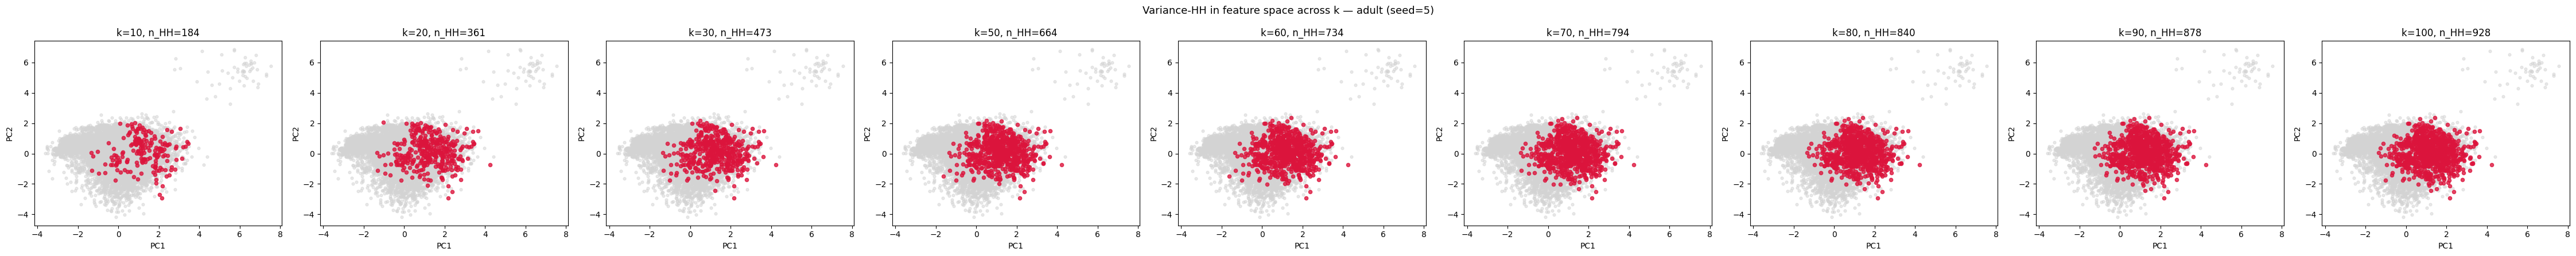

compas: representative seed = seed=2 (median Moran's I = 0.1796)


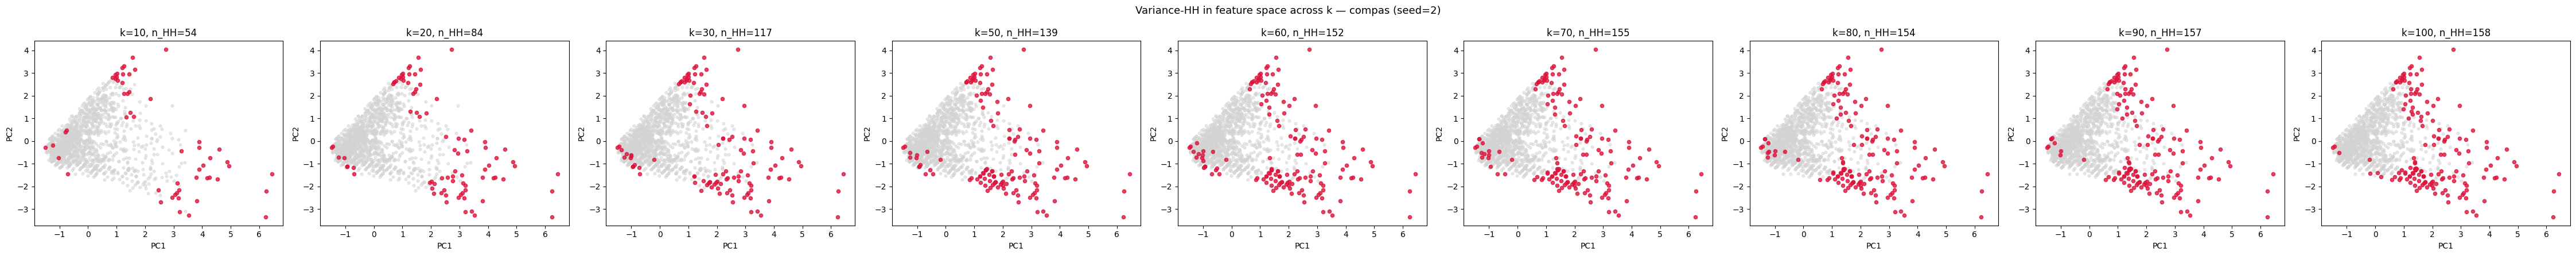

german: representative seed = seed=0 (median Moran's I = 0.0575)


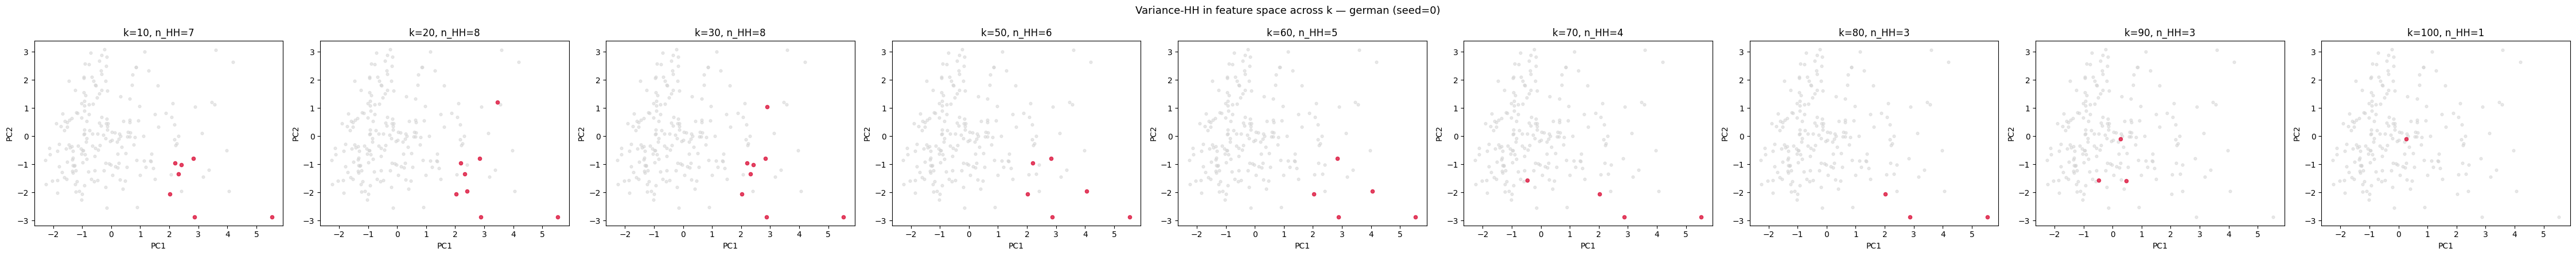

In [6]:
# Rebuild hh_data_by_knn from cached overlay (X_test loaded per run for plotting only)
hh_data_by_knn = {}
for (dataset_name, seed_name, k_nn_val), grp in df_hh_overlay.groupby(["dataset", "seed", "k_nn"]):
    run_dir = RESULTS_DIR / dataset_name / seed_name
    X_test = get_transformed_test_features(run_dir, dataset_name)
    hh_mask = grp.sort_values("point_idx")["is_hh"].to_numpy(dtype=bool)
    hh_data_by_knn[(dataset_name, seed_name, k_nn_val)] = {"HH_mask": hh_mask, "X_test": X_test}

for ds_name in df_knn["dataset"].unique():
    ds_sub = df_knn[(df_knn["dataset"] == ds_name)]
    seeds = ds_sub["seed"].unique()

    moran_per_seed = ds_sub.groupby("seed")["moran_i"].mean()
    median_moran = moran_per_seed.median()
    rep_seed = moran_per_seed.index[np.argmin(np.abs(moran_per_seed.values - median_moran))]
    print(f"{ds_name}: representative seed = {rep_seed} (median Moran's I = {median_moran:.4f})")

    k_list = sorted(ds_sub["k_nn"].unique())
    n_k = len(k_list)
    fig, axes = plt.subplots(1, n_k, figsize=(5 * n_k, 4.5))
    if n_k == 1:
        axes = [axes]

    for ax, k_val in zip(axes, k_list):
        key = (ds_name, rep_seed, k_val)
        if key not in hh_data_by_knn:
            ax.set_title(f"k={k_val} (no data)")
            continue
        data = hh_data_by_knn[key]
        X_test = data["X_test"]
        hh = data["HH_mask"]
        n_features = X_test.shape[1]
        if n_features > 2:
            pca = PCA(n_components=2, random_state=42)
            coords = pca.fit_transform(X_test)
        else:
            coords = np.asarray(X_test)

        ax.scatter(coords[~hh, 0], coords[~hh, 1], c="lightgray", s=12, alpha=0.5)
        ax.scatter(coords[hh, 0], coords[hh, 1], c="crimson", s=20, alpha=0.8)
        ax.set_title(f"k={k_val}, n_HH={int(hh.sum())}")
        ax.set_xlabel("PC1" if n_features > 2 else "Feature 1")
        ax.set_ylabel("PC2" if n_features > 2 else "Feature 2")

    fig.suptitle(f"Variance-HH in feature space across k — {ds_name} ({rep_seed})", fontsize=13)
    fig.tight_layout()
    fig.savefig(FIG_DIR / f"sensitivity_kNN_pca_hh_{ds_name}.pdf", bbox_inches="tight")
    plt.show()

## Interpret stability

If spatial statistics change little for k ≥ 20–30, the kNN graph choice is stable.

**Notebook maintenance:** The connectivity aggregation above drives `chosen_k_df` and should be kept in sync with `analysis/knn_defaults.py` (`K_NN_BY_DATASET`). After changing the k grid or re-running experiments, re-run this notebook and update the mapping if `chosen_k` changes.